# 07d — Selected Peptide Molecular-Dynamics Comparison

## Pipeline 3 — Molecular Dynamics

This notebook compares three selected peptide complexes:

```text
F0010  — natural 11-aa reference
CF06   — best integrated Rosetta counterfactual
CF02   — strongest FoldX/oracle counterfactual
```

Current sequences:

```text
F0010 = IGERCQYRDLK
CF06  = IGERCQYRELR
CF02  = IGERSQYRELK
```

The purpose is to ask:

> Do the optimized counterfactual peptides preserve the dynamic interface behaviour of the natural F0010 reference?

---

## Workflow

```text
selected bound structures
        ↓
OpenMM preparation
        ↓
solvation + ions
        ↓
minimization
        ↓
NVT + NPT equilibration
        ↓
short production MD
        ↓
protein/peptide trajectory
        ↓
receptor-aligned analysis
        ↓
RMSD / RMSF / contact persistence
        ↓
F0010 vs CF06 vs CF02 comparison
```

---

## Important scope

This notebook is a **comparative prototype MD analysis**.

It does not prove affinity, inhibition or biological activity.

A more rigorous production study would require:
- longer trajectories;
- independent replicates;
- convergence analysis;
- free-energy calculations;
- experimental validation.


## 1. Imports

In [12]:
from pathlib import Path
from collections import Counter
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pdbfixer import PDBFixer

from openmm import (
    Platform,
    LangevinMiddleIntegrator,
    MonteCarloBarostat,
    XmlSerializer,
    unit,
)

from openmm.app import (
    PDBFile,
    Modeller,
    ForceField,
    Simulation,
    PME,
    HBonds,
    DCDReporter,
    StateDataReporter,
)

import MDAnalysis as mda
from MDAnalysis.analysis import align
from MDAnalysis.analysis.rms import RMSD, RMSF
from MDAnalysis.lib.distances import capped_distance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Imports OK")


Imports OK


## 2. Configuration

In [13]:
# ------------------------------------------------------
# Candidate definitions
# ------------------------------------------------------
CANDIDATES = {
    "F0010": {
        "sequence": "IGERCQYRDLK",
        "description": "natural reference",
    },
    "CF06": {
        "sequence": "IGERCQYRELR",
        "description": "best integrated Rosetta counterfactual",
    },
    "CF02": {
        "sequence": "IGERSQYRELK",
        "description": "strongest FoldX/oracle counterfactual",
    },
}

RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

# ------------------------------------------------------
# MD parameters
# ------------------------------------------------------
TEMPERATURE_K = 300.0
PRESSURE_BAR = 1.0
FRICTION_PER_PS = 1.0
TIMESTEP_PS = 0.002

PADDING_NM = 1.0
IONIC_STRENGTH_M = 0.15

PME_CUTOFF_NM = 1.0

MINIMIZATION_MAX_ITER = 5000

# ------------------------------------------------------
# Runtime mode
# ------------------------------------------------------
FAST_TEST_MODE = False

if FAST_TEST_MODE:
    NVT_PS = 10.0
    NPT_PS = 10.0
    PRODUCTION_PS = 50.0
    FRAME_INTERVAL_PS = 2.0
else:
    NVT_PS = 100.0
    NPT_PS = 100.0
    PRODUCTION_PS = 1000.0
    FRAME_INTERVAL_PS = 2.0

STATE_INTERVAL_PS = 10.0

# ------------------------------------------------------
# Contact analysis
# ------------------------------------------------------
CONTACT_CUTOFF_A = 4.5
PERSISTENCE_THRESHOLD = 0.50

# ------------------------------------------------------
# Random seed
# ------------------------------------------------------
BASE_RANDOM_SEED = 20260808

# ------------------------------------------------------
# Output
# ------------------------------------------------------
RUN_LABEL = (
    "test_50ps"
    if FAST_TEST_MODE
    else "production_1ns"
)

OUTPUT_ROOT = (
    Path("outputs")
    / "pipeline_3_md_07d_selected_peptide_comparison"
    / RUN_LABEL
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("FAST_TEST_MODE:", FAST_TEST_MODE)
print("NVT:", NVT_PS, "ps")
print("NPT:", NPT_PS, "ps")
print("Production:", PRODUCTION_PS, "ps")
print("Run label:", RUN_LABEL)
print("Output:", OUTPUT_ROOT.resolve())


FAST_TEST_MODE: False
NVT: 100.0 ps
NPT: 100.0 ps
Production: 1000.0 ps
Run label: production_1ns
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns


In [14]:
from pathlib import Path

for key in ["CF06", "CF02"]:
    print(f"\n--- {key} ---")
    for p in Path("outputs").rglob("*.pdb"):
        if key.lower() in p.name.lower():
            print(p)


--- CF06 ---
outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns/CF06/structures/CF06_BD_solvated.pdb
outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns/CF06/structures/CF06_minimized.pdb
outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns/CF06/structures/CF06_BD_cleaned.pdb
outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns/CF06/trajectory/CF06_protein_topology.pdb
outputs/pipeline_3_md_07d_selected_peptide_comparison/test_50ps/CF06/structures/CF06_BD_solvated.pdb
outputs/pipeline_3_md_07d_selected_peptide_comparison/test_50ps/CF06/structures/CF06_minimized.pdb
outputs/pipeline_3_md_07d_selected_peptide_comparison/test_50ps/CF06/structures/CF06_BD_cleaned.pdb
outputs/pipeline_3_md_07d_selected_peptide_comparison/test_50ps/CF06/trajectory/CF06_protein_topology.pdb

--- CF02 ---
outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns/CF02/structures/CF02_BD_solvated.pdb
outputs/pipeline_3_md_07d_selected

In [15]:
from pathlib import Path
import MDAnalysis as mda

THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

targets = {
    "CF06": "IGERCQYRELR",
    "CF02": "IGERSQYRELK",
}

for pdb in Path("outputs").rglob("*.pdb"):
    try:
        u = mda.Universe(str(pdb))

        if "D" in set(u.atoms.chainIDs):
            pep = u.select_atoms("chainID D")
        else:
            continue

        seq = "".join(
            THREE_TO_ONE.get(res.resname.upper(), "")
            for res in pep.residues
        )

        for name, target_seq in targets.items():
            if seq == target_seq:
                print(f"{name} FOUND")
                print(pdb)
                print()
    except Exception:
        pass

CF02 FOUND
outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0006/F0010_native_complex_18.pdb

CF06 FOUND
outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/chunks/chunk_0001/F0010_native_complex_50.pdb

CF06 FOUND
outputs/clear_local_peptide_dataset_04c/variant_models/V00050.pdb

CF02 FOUND
outputs/clear_local_peptide_dataset_04c/variant_models/V00268.pdb

CF02 FOUND
outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_02_IGERSQYRELK.pdb

CF06 FOUND
outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_06_IGERCQYRELR.pdb

CF02 FOUND
outputs/clear_counterfactual_validation_05c/rosetta_candidates/RC_01_CF_02.pdb

CF06 FOUND
outputs/clear_counterfactual_validation_05c/rosetta_candidates/RC_04_CF_06.pdb

CF02 FOUND
outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_2.pdb

CF06 FOUND
outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_6.pdb

CF02 FOUND
outputs/clear_counter

In [7]:
print(candidate_pdbs["F0010"])

outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/F0010_native_complex.pdb


## 3. Locate bound structures

The notebook searches recursively for PDB files whose filenames contain the candidate name.

Priority is given to files that also contain words such as:

```text
best
refined
complex
rosetta
flexpepdock
```

This is deliberately transparent: the selected file for each candidate is printed before MD begins.

If the automatic search chooses the wrong file, set `MANUAL_PDB_FILES` explicitly.


In [16]:
MANUAL_PDB_FILES = {
    "F0010": Path(
        "outputs/clear_local_peptide_dataset_04c/"
        "foldx_buildmodel/"
        "F0010_native_complex.pdb"
    ),

    "CF06": Path(
        "outputs/clear_counterfactual_flexpepdock_05d/"
        "best_poses/"
        "CF_06_best.pdb"
    ),

    "CF02": Path(
        "outputs/clear_counterfactual_flexpepdock_05d/"
        "best_poses/"
        "CF_02_best.pdb"
    ),
}

SEARCH_ROOTS = [
    Path("outputs"),
    Path("."),
]

PREFERRED_TERMS = [
    "best",
    "refined",
    "complex",
    "rosetta",
    "flexpepdock",
]

def score_path(path, candidate_name):
    name = path.name.lower()
    score = 0

    if candidate_name.lower() in name:
        score += 100

    for term in PREFERRED_TERMS:
        if term in name:
            score += 10

    # Prefer smaller directory depth modestly.
    score -= 0.1 * len(path.parts)

    return score

def find_candidate_pdb(candidate_name):
    manual = MANUAL_PDB_FILES.get(candidate_name)

    if manual is not None:
        manual = Path(manual)

        if not manual.exists():
            raise FileNotFoundError(
                f"Manual PDB for {candidate_name} does not exist: {manual}"
            )

        return manual

    matches = []

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue

        for path in root.rglob("*.pdb"):
            if candidate_name.lower() in path.name.lower():
                matches.append(path)

    if not matches:
        return None

    matches = sorted(
        matches,
        key=lambda p: score_path(p, candidate_name),
        reverse=True,
    )

    return matches[0]

candidate_pdbs = {
    name: find_candidate_pdb(name)
    for name in CANDIDATES
}

selection_table = pd.DataFrame([
    {
        "candidate": name,
        "sequence": CANDIDATES[name]["sequence"],
        "selected_pdb": str(path) if path else None,
        "exists": bool(path and path.exists()),
    }
    for name, path in candidate_pdbs.items()
])

display(selection_table)


,candidate,sequence,selected_pdb,exists
0,F0010,IGERCQYRDLK,outputs/clear_local_peptide_dataset_04c/foldx_...,True
1,CF06,IGERCQYRELR,outputs/clear_counterfactual_flexpepdock_05d/b...,True
2,CF02,IGERSQYRELK,outputs/clear_counterfactual_flexpepdock_05d/b...,True


## 4. Validate the selected structures

Each selected structure should contain:
- receptor chain B;
- peptide chain D.

This notebook also checks the peptide sequence recovered from the PDB.

If the recovered sequence does not match the expected candidate sequence, the notebook stops rather than silently running the wrong complex.


In [17]:
THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

def inspect_pdb(path):
    u = mda.Universe(str(path))

    chain_ids = sorted(
        set(
            str(x)
            for x in u.atoms.chainIDs
            if str(x)
        )
    )

    if not chain_ids:
        chain_ids = sorted(
            set(
                str(x)
                for x in u.atoms.segids
                if str(x)
            )
        )

    if PEPTIDE_CHAIN in set(u.atoms.chainIDs):
        pep = u.select_atoms(f"chainID {PEPTIDE_CHAIN}")
    else:
        pep = u.select_atoms(f"segid {PEPTIDE_CHAIN}")

    residue_names = [
        res.resname.upper()
        for res in pep.residues
        if res.resname.upper() in THREE_TO_ONE
    ]

    sequence = "".join(
        THREE_TO_ONE[r]
        for r in residue_names
    )

    return {
        "chain_ids": chain_ids,
        "peptide_sequence": sequence,
        "n_atoms": len(u.atoms),
        "n_peptide_residues": len(residue_names),
    }

validation_rows = []

for name, path in candidate_pdbs.items():

    if path is None:
        validation_rows.append({
            "candidate": name,
            "status": "MISSING_PDB",
            "selected_pdb": None,
            "expected_sequence": CANDIDATES[name]["sequence"],
            "observed_sequence": None,
        })
        continue

    info = inspect_pdb(path)

    expected = CANDIDATES[name]["sequence"]
    observed = info["peptide_sequence"]

    receptor_present = RECEPTOR_CHAIN in info["chain_ids"]
    peptide_present = PEPTIDE_CHAIN in info["chain_ids"]
    sequence_match = expected == observed

    status = (
        "PASS"
        if receptor_present and peptide_present and sequence_match
        else "FAIL"
    )

    validation_rows.append({
        "candidate": name,
        "status": status,
        "selected_pdb": str(path),
        "chains": ",".join(info["chain_ids"]),
        "expected_sequence": expected,
        "observed_sequence": observed,
        "sequence_match": sequence_match,
        "n_atoms": info["n_atoms"],
        "n_peptide_residues": info["n_peptide_residues"],
    })

validation_df = pd.DataFrame(validation_rows)

display(validation_df)

if not (validation_df["status"] == "PASS").all():
    raise RuntimeError(
        "One or more candidate structures failed validation. "
        "Fix MANUAL_PDB_FILES before continuing."
    )

print("Structure validation: PASS")


,candidate,status,selected_pdb,chains,expected_sequence,observed_sequence,sequence_match,n_atoms,n_peptide_residues
0,F0010,PASS,outputs/clear_local_peptide_dataset_04c/foldx_...,"B,D",IGERCQYRDLK,IGERCQYRDLK,True,4825,11
1,CF06,PASS,outputs/clear_counterfactual_flexpepdock_05d/b...,"B,D",IGERCQYRELR,IGERCQYRELR,True,9485,11
2,CF02,PASS,outputs/clear_counterfactual_flexpepdock_05d/b...,"B,D",IGERSQYRELK,IGERSQYRELK,True,9483,11


Structure validation: PASS


## 5. Select OpenMM platform

In [18]:
def choose_platform():
    platform_names = [
        Platform.getPlatform(i).getName()
        for i in range(Platform.getNumPlatforms())
    ]

    for preferred in [
        "CUDA",
        "OpenCL",
        "CPU",
        "Reference",
    ]:
        if preferred in platform_names:
            return Platform.getPlatformByName(preferred)

    raise RuntimeError("No OpenMM platform available.")

platform = choose_platform()

print("OpenMM platform:", platform.getName())


OpenMM platform: OpenCL


## 6. Helper — prepare one bound complex

For each candidate:
1. PDBFixer cleans the receptor–peptide PDB;
2. only chains B and D are retained;
3. hydrogens are added at pH 7.4;
4. explicit TIP3P water and 0.15 M NaCl are added;
5. the system is parameterized with AMBER14SB/TIP3P.


In [19]:
FORCEFIELD_FILES = [
    "amber14/protein.ff14SB.xml",
    "amber14/tip3p.xml",
]

def prepare_candidate_system(
    candidate_name,
    pdb_path,
    random_seed,
):
    candidate_dir = OUTPUT_ROOT / candidate_name

    structure_dir = candidate_dir / "structures"
    state_dir = candidate_dir / "states"
    log_dir = candidate_dir / "logs"
    trajectory_dir = candidate_dir / "trajectory"
    analysis_dir = candidate_dir / "analysis"

    for d in [
        candidate_dir,
        structure_dir,
        state_dir,
        log_dir,
        trajectory_dir,
        analysis_dir,
    ]:
        d.mkdir(
            parents=True,
            exist_ok=True,
        )

    fixer = PDBFixer(
        filename=str(pdb_path)
    )

    # Keep only receptor + peptide chains.
    chains_to_remove = [
        chain.id
        for chain in fixer.topology.chains()
        if chain.id not in {
            RECEPTOR_CHAIN,
            PEPTIDE_CHAIN,
        }
    ]

    if chains_to_remove:
        fixer.removeChains(
            chainIds=chains_to_remove
        )

    fixer.findMissingResidues()
    fixer.findNonstandardResidues()
    fixer.replaceNonstandardResidues()
    fixer.removeHeterogens(
        keepWater=False
    )
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(
        pH=7.4
    )

    cleaned_pdb = (
        structure_dir
        / f"{candidate_name}_BD_cleaned.pdb"
    )

    with cleaned_pdb.open("w") as handle:
        PDBFile.writeFile(
            fixer.topology,
            fixer.positions,
            handle,
            keepIds=True,
        )

    forcefield = ForceField(
        *FORCEFIELD_FILES
    )

    modeller = Modeller(
        fixer.topology,
        fixer.positions,
    )

    modeller.addSolvent(
        forcefield,
        model="tip3p",
        padding=PADDING_NM * unit.nanometer,
        ionicStrength=IONIC_STRENGTH_M * unit.molar,
        positiveIon="Na+",
        negativeIon="Cl-",
    )

    solvated_pdb = (
        structure_dir
        / f"{candidate_name}_BD_solvated.pdb"
    )

    with solvated_pdb.open("w") as handle:
        PDBFile.writeFile(
            modeller.topology,
            modeller.positions,
            handle,
            keepIds=True,
        )

    system = forcefield.createSystem(
        modeller.topology,
        nonbondedMethod=PME,
        nonbondedCutoff=PME_CUTOFF_NM
        * unit.nanometer,
        constraints=HBonds,
    )

    system.addForce(
        MonteCarloBarostat(
            PRESSURE_BAR * unit.bar,
            TEMPERATURE_K * unit.kelvin,
            25,
        )
    )

    integrator = LangevinMiddleIntegrator(
        TEMPERATURE_K * unit.kelvin,
        FRICTION_PER_PS / unit.picosecond,
        TIMESTEP_PS * unit.picoseconds,
    )

    integrator.setRandomNumberSeed(
        int(random_seed)
    )

    simulation = Simulation(
        modeller.topology,
        system,
        integrator,
        platform,
    )

    simulation.context.setPositions(
        modeller.positions
    )

    system_xml = (
        state_dir
        / f"{candidate_name}_system.xml"
    )

    system_xml.write_text(
        XmlSerializer.serialize(system),
        encoding="utf-8",
    )

    return {
        "candidate": candidate_name,
        "candidate_dir": candidate_dir,
        "structure_dir": structure_dir,
        "state_dir": state_dir,
        "log_dir": log_dir,
        "trajectory_dir": trajectory_dir,
        "analysis_dir": analysis_dir,
        "cleaned_pdb": cleaned_pdb,
        "solvated_pdb": solvated_pdb,
        "simulation": simulation,
        "topology": modeller.topology,
        "system": system,
    }


## 7. Helper — run minimization, equilibration and production

In [20]:
def ps_to_steps(ps):
    return int(
        round(
            ps / TIMESTEP_PS
        )
    )

def run_candidate_md(
    prepared,
    candidate_index,
):
    candidate_name = prepared["candidate"]
    simulation = prepared["simulation"]

    state_dir = prepared["state_dir"]
    log_dir = prepared["log_dir"]
    trajectory_dir = prepared["trajectory_dir"]
    analysis_dir = prepared["analysis_dir"]

    print("\n" + "=" * 72)
    print("Running:", candidate_name)
    print("=" * 72)

    # ----------------------------------------------
    # Minimize
    # ----------------------------------------------
    t0 = time.time()

    simulation.minimizeEnergy(
        maxIterations=MINIMIZATION_MAX_ITER
    )

    minimized_state = simulation.context.getState(
        getPositions=True,
        getEnergy=True,
    )

    minimized_pdb = (
        prepared["structure_dir"]
        / f"{candidate_name}_minimized.pdb"
    )

    with minimized_pdb.open("w") as handle:
        PDBFile.writeFile(
            prepared["topology"],
            minimized_state.getPositions(),
            handle,
            keepIds=True,
        )

    # ----------------------------------------------
    # NVT
    # ----------------------------------------------
    simulation.context.setVelocitiesToTemperature(
        TEMPERATURE_K * unit.kelvin,
        BASE_RANDOM_SEED + candidate_index,
    )

    nvt_steps = ps_to_steps(NVT_PS)

    simulation.step(
        nvt_steps
    )

    # ----------------------------------------------
    # NPT
    # ----------------------------------------------
    npt_steps = ps_to_steps(NPT_PS)

    simulation.step(
        npt_steps
    )

    equilibrated_state = simulation.context.getState(
        getPositions=True,
        getVelocities=True,
        getEnergy=True,
        enforcePeriodicBox=True,
    )

    equilibrated_xml = (
        state_dir
        / f"{candidate_name}_equilibrated_state.xml"
    )

    equilibrated_xml.write_text(
        XmlSerializer.serialize(
            equilibrated_state
        ),
        encoding="utf-8",
    )

    # ----------------------------------------------
    # Protein-only DCD selection
    # ----------------------------------------------
    protein_atom_indices = []

    for atom in prepared["topology"].atoms():
        if atom.residue.chain.id in {
            RECEPTOR_CHAIN,
            PEPTIDE_CHAIN,
        }:
            protein_atom_indices.append(
                atom.index
            )

    protein_topology_pdb = (
        trajectory_dir
        / f"{candidate_name}_protein_topology.pdb"
    )

    protein_positions = [
        equilibrated_state.getPositions()[i]
        for i in protein_atom_indices
    ]

    # Create a protein-only Modeller to write topology cleanly.
    temp_modeller = Modeller(
        prepared["topology"],
        equilibrated_state.getPositions(),
    )

    atoms_to_delete = [
        atom
        for atom in temp_modeller.topology.atoms()
        if atom.index not in set(protein_atom_indices)
    ]

    temp_modeller.delete(
        atoms_to_delete
    )

    with protein_topology_pdb.open("w") as handle:
        PDBFile.writeFile(
            temp_modeller.topology,
            temp_modeller.positions,
            handle,
            keepIds=True,
        )

    # ----------------------------------------------
    # Production reporters
    # ----------------------------------------------
    frame_interval_steps = ps_to_steps(
        FRAME_INTERVAL_PS
    )

    state_interval_steps = ps_to_steps(
        STATE_INTERVAL_PS
    )

    dcd_path = (
        trajectory_dir
        / f"{candidate_name}_{RUN_LABEL}_protein.dcd"
    )

    log_path = (
        log_dir
        / f"{candidate_name}_{RUN_LABEL}.csv"
    )

    simulation.reporters = []

    simulation.reporters.append(
        DCDReporter(
            str(dcd_path),
            frame_interval_steps,
            atomSubset=protein_atom_indices,
            enforcePeriodicBox=False,
        )
    )

    simulation.reporters.append(
        StateDataReporter(
            str(log_path),
            state_interval_steps,
            step=True,
            time=True,
            potentialEnergy=True,
            kineticEnergy=True,
            totalEnergy=True,
            temperature=True,
            volume=True,
            density=True,
            speed=True,
            separator=",",
        )
    )

    production_steps = ps_to_steps(
        PRODUCTION_PS
    )

    print(
        f"Production: {PRODUCTION_PS:.1f} ps "
        f"({production_steps:,} steps)"
    )

    simulation.step(
        production_steps
    )

    final_state = simulation.context.getState(
        getPositions=True,
        getVelocities=True,
        getEnergy=True,
        enforcePeriodicBox=True,
    )

    final_xml = (
        state_dir
        / f"{candidate_name}_{RUN_LABEL}_final_state.xml"
    )

    final_xml.write_text(
        XmlSerializer.serialize(
            final_state
        ),
        encoding="utf-8",
    )

    elapsed_min = (
        time.time() - t0
    ) / 60.0

    print(
        f"{candidate_name} completed in "
        f"{elapsed_min:.2f} min"
    )

    return {
        "candidate": candidate_name,
        "protein_topology_pdb": protein_topology_pdb,
        "dcd_path": dcd_path,
        "log_path": log_path,
        "elapsed_min": elapsed_min,
        "analysis_dir": analysis_dir,
    }


## 8. Run the MD simulations

### Important

In `FAST_TEST_MODE=True` each candidate runs only:

```text
10 ps NVT
10 ps NPT
50 ps production
```

Use this first to confirm that the full pipeline works.

Only after the test succeeds, set:

```python
FAST_TEST_MODE = False
```

to run:

```text
100 ps NVT
100 ps NPT
1 ns production
```

for each candidate.


In [21]:
prepared_systems = {}

for idx, (name, pdb_path) in enumerate(
    candidate_pdbs.items()
):
    print("\nPreparing:", name)

    prepared_systems[name] = (
        prepare_candidate_system(
            candidate_name=name,
            pdb_path=pdb_path,
            random_seed=BASE_RANDOM_SEED + idx,
        )
    )

print("\nAll candidate systems prepared.")



Preparing: F0010

Preparing: CF06

Preparing: CF02

All candidate systems prepared.


In [22]:
md_results = {}

for idx, name in enumerate(CANDIDATES):
    md_results[name] = run_candidate_md(
        prepared_systems[name],
        candidate_index=idx,
    )

print("\nAll MD runs completed.")



Running: F0010
Production: 1000.0 ps (500,000 steps)
F0010 completed in 71.17 min

Running: CF06
Production: 1000.0 ps (500,000 steps)
CF06 completed in 71.01 min

Running: CF02
Production: 1000.0 ps (500,000 steps)
CF02 completed in 72.39 min

All MD runs completed.


## 9. Thermodynamic QC

In [23]:
qc_rows = []

for name, result in md_results.items():

    log_df = pd.read_csv(
        result["log_path"]
    )

    temperature_col = [
        c
        for c in log_df.columns
        if "Temperature" in c
    ][0]

    density_col = [
        c
        for c in log_df.columns
        if "Density" in c
    ][0]

    mean_temp = (
        log_df[temperature_col]
        .astype(float)
        .mean()
    )

    sd_temp = (
        log_df[temperature_col]
        .astype(float)
        .std()
    )

    mean_density = (
        log_df[density_col]
        .astype(float)
        .mean()
    )

    qc_rows.append({
        "candidate": name,
        "mean_temperature_K": mean_temp,
        "sd_temperature_K": sd_temp,
        "mean_density_g_mL": mean_density,
        "temperature_OK": abs(
            mean_temp - TEMPERATURE_K
        ) <= 5.0,
        "density_OK": (
            0.95
            <= mean_density
            <= 1.05
        ),
    })

qc_df = pd.DataFrame(qc_rows)

qc_df["QC_PASS"] = (
    qc_df["temperature_OK"]
    & qc_df["density_OK"]
)

display(qc_df)

qc_df.to_csv(
    OUTPUT_ROOT / "thermodynamic_qc.csv",
    index=False,
)

print(
    "ALL QC PASSED:",
    bool(qc_df["QC_PASS"].all()),
)


,candidate,mean_temperature_K,sd_temperature_K,mean_density_g_mL,temperature_OK,density_OK,QC_PASS
0,F0010,300.263891,0.540636,1.001927,True,True,True
1,CF06,300.236596,0.545978,1.001783,True,True,True
2,CF02,300.314283,0.527314,1.002017,True,True,True


ALL QC PASSED: True


## 10. Helper — trajectory analysis

In [24]:
def get_chain_selection(
    universe,
    chain_id,
):
    chain_ids = set(
        str(x)
        for x in universe.atoms.chainIDs
    )

    if chain_id in chain_ids:
        return f"chainID {chain_id}"

    segids = set(
        str(x)
        for x in universe.atoms.segids
    )

    if chain_id in segids:
        return f"segid {chain_id}"

    raise ValueError(
        f"Cannot identify chain {chain_id}"
    )

def analyze_candidate_trajectory(
    candidate_name,
    topology_pdb,
    dcd_path,
    analysis_dir,
):
    u = mda.Universe(
        str(topology_pdb),
        str(dcd_path),
    )

    sel_B = get_chain_selection(
        u,
        RECEPTOR_CHAIN,
    )

    sel_D = get_chain_selection(
        u,
        PEPTIDE_CHAIN,
    )

    # ----------------------------------------------
    # Align all frames to receptor CA
    # ----------------------------------------------
    align.AlignTraj(
        u,
        u,
        select=f"({sel_B}) and name CA",
        in_memory=True,
    ).run()

    B_ca = u.select_atoms(
        f"({sel_B}) and name CA"
    )

    D_ca = u.select_atoms(
        f"({sel_D}) and name CA"
    )

    complex_ca = u.select_atoms(
        (
            f"(({sel_B}) or ({sel_D})) "
            f"and name CA"
        )
    )

    # ----------------------------------------------
    # RMSD relative to first frame
    # ----------------------------------------------
    ref_B = B_ca.positions.copy()
    ref_D = D_ca.positions.copy()
    ref_complex = complex_ca.positions.copy()

    rmsd_rows = []

    def rmsd_A(
        positions,
        reference,
    ):
        diff = positions - reference

        return float(
            np.sqrt(
                np.mean(
                    np.sum(
                        diff * diff,
                        axis=1,
                    )
                )
            )
        )

    for frame_idx, ts in enumerate(u.trajectory):
        rmsd_rows.append({
            "frame": frame_idx,
            "time_ps": float(ts.time),
            "B_CA_RMSD_A": rmsd_A(
                B_ca.positions,
                ref_B,
            ),
            "D_CA_RMSD_A": rmsd_A(
                D_ca.positions,
                ref_D,
            ),
            "complex_CA_RMSD_A": rmsd_A(
                complex_ca.positions,
                ref_complex,
            ),
        })

    rmsd_df = pd.DataFrame(
        rmsd_rows
    )

    rmsd_df.to_csv(
        analysis_dir
        / "rmsd_timeseries.csv",
        index=False,
    )

    # ----------------------------------------------
    # RMSF
    # ----------------------------------------------
    u.trajectory[0]

    rmsf_B = RMSF(
        B_ca
    ).run()

    rmsf_D = RMSF(
        D_ca
    ).run()

    rmsf_rows = []

    for atom, value in zip(
        B_ca,
        rmsf_B.results.rmsf,
    ):
        rmsf_rows.append({
            "candidate": candidate_name,
            "chain": RECEPTOR_CHAIN,
            "resid": int(atom.resid),
            "resname": atom.resname,
            "CA_RMSF_A": float(value),
        })

    for atom, value in zip(
        D_ca,
        rmsf_D.results.rmsf,
    ):
        rmsf_rows.append({
            "candidate": candidate_name,
            "chain": PEPTIDE_CHAIN,
            "resid": int(atom.resid),
            "resname": atom.resname,
            "CA_RMSF_A": float(value),
        })

    rmsf_df = pd.DataFrame(
        rmsf_rows
    )

    rmsf_df.to_csv(
        analysis_dir
        / "rmsf_by_residue.csv",
        index=False,
    )

    # ----------------------------------------------
    # B-D heavy-atom contact persistence
    # ----------------------------------------------
    B_heavy = u.select_atoms(
        f"({sel_B}) and not name H*"
    )

    D_heavy = u.select_atoms(
        f"({sel_D}) and not name H*"
    )

    contact_counter = Counter()
    distance_sum = Counter()

    n_frames = 0

    for ts in u.trajectory:
        n_frames += 1

        pairs, distances = capped_distance(
            B_heavy.positions,
            D_heavy.positions,
            max_cutoff=CONTACT_CUTOFF_A,
            box=None,
            return_distances=True,
        )

        frame_contacts = {}

        for pair, distance in zip(
            pairs,
            distances,
        ):
            atom_B = B_heavy[
                int(pair[0])
            ]
            atom_D = D_heavy[
                int(pair[1])
            ]

            key = (
                atom_B.residue.resname,
                int(atom_B.residue.resid),
                atom_D.residue.resname,
                int(atom_D.residue.resid),
            )

            if (
                key not in frame_contacts
                or distance < frame_contacts[key]
            ):
                frame_contacts[key] = float(
                    distance
                )

        for key, distance in frame_contacts.items():
            contact_counter[key] += 1
            distance_sum[key] += distance

    contact_rows = []

    for key, count in contact_counter.items():
        (
            B_resname,
            B_resid,
            D_resname,
            D_resid,
        ) = key

        persistence = (
            count / n_frames
        )

        contact_rows.append({
            "candidate": candidate_name,
            "B_resname": B_resname,
            "B_resid": B_resid,
            "D_resname": D_resname,
            "D_resid": D_resid,
            "frames_in_contact": count,
            "n_frames": n_frames,
            "persistence": persistence,
            "persistence_percent": persistence * 100,
            "mean_min_distance_A": (
                distance_sum[key] / count
            ),
            "persistent_50pct": (
                persistence
                >= PERSISTENCE_THRESHOLD
            ),
        })

    contact_df = pd.DataFrame(
        contact_rows
    )

    if not contact_df.empty:
        contact_df = (
            contact_df
            .sort_values(
                [
                    "persistence",
                    "mean_min_distance_A",
                ],
                ascending=[
                    False,
                    True,
                ],
            )
            .reset_index(drop=True)
        )

    contact_df.to_csv(
        analysis_dir
        / "BD_contact_persistence.csv",
        index=False,
    )

    summary = {
        "candidate": candidate_name,
        "n_frames": n_frames,
        "mean_B_CA_RMSD_A": (
            rmsd_df["B_CA_RMSD_A"]
            .mean()
        ),
        "mean_D_CA_RMSD_A": (
            rmsd_df["D_CA_RMSD_A"]
            .mean()
        ),
        "mean_complex_CA_RMSD_A": (
            rmsd_df["complex_CA_RMSD_A"]
            .mean()
        ),
        "mean_D_CA_RMSF_A": (
            rmsf_df.loc[
                rmsf_df["chain"]
                == PEPTIDE_CHAIN,
                "CA_RMSF_A",
            ]
            .mean()
        ),
        "n_unique_contacts": len(
            contact_df
        ),
        "n_persistent_contacts_50pct": int(
            contact_df["persistent_50pct"]
            .sum()
        ) if len(contact_df) else 0,
        "mean_contact_persistence": (
            contact_df["persistence"]
            .mean()
        ) if len(contact_df) else np.nan,
    }

    return {
        "rmsd_df": rmsd_df,
        "rmsf_df": rmsf_df,
        "contact_df": contact_df,
        "summary": summary,
    }


## 11. Analyze all candidate trajectories

In [25]:
analysis_results = {}

for name, result in md_results.items():

    print("Analyzing:", name)

    analysis_results[name] = (
        analyze_candidate_trajectory(
            candidate_name=name,
            topology_pdb=result[
                "protein_topology_pdb"
            ],
            dcd_path=result[
                "dcd_path"
            ],
            analysis_dir=result[
                "analysis_dir"
            ],
        )
    )

print("Trajectory analysis complete.")


Analyzing: F0010
Analyzing: CF06
Analyzing: CF02
Trajectory analysis complete.


## 12. Main comparative summary

In [26]:
comparison_df = pd.DataFrame([
    result["summary"]
    for result in analysis_results.values()
])

comparison_df = comparison_df.merge(
    qc_df[
        [
            "candidate",
            "mean_temperature_K",
            "mean_density_g_mL",
            "QC_PASS",
        ]
    ],
    on="candidate",
    how="left",
)

comparison_df["sequence"] = (
    comparison_df["candidate"]
    .map(
        lambda x: CANDIDATES[x]["sequence"]
    )
)

comparison_df.to_csv(
    OUTPUT_ROOT
    / "07d_selected_peptide_MD_comparison.csv",
    index=False,
)

display(
    comparison_df[
        [
            "candidate",
            "sequence",
            "n_frames",
            "mean_D_CA_RMSD_A",
            "mean_D_CA_RMSF_A",
            "n_unique_contacts",
            "n_persistent_contacts_50pct",
            "mean_contact_persistence",
            "mean_temperature_K",
            "mean_density_g_mL",
            "QC_PASS",
        ]
    ]
)


,candidate,sequence,n_frames,mean_D_CA_RMSD_A,mean_D_CA_RMSF_A,n_unique_contacts,n_persistent_contacts_50pct,mean_contact_persistence,mean_temperature_K,mean_density_g_mL,QC_PASS
0,F0010,IGERCQYRDLK,500,1.965916,1.163706,81,43,0.540519,300.263891,1.001927,True
1,CF06,IGERCQYRELR,500,1.293427,0.903728,88,45,0.528545,300.236596,1.001783,True
2,CF02,IGERSQYRELK,500,0.901385,0.737052,70,43,0.602886,300.314283,1.002017,True


## 13. Peptide RMSD comparison

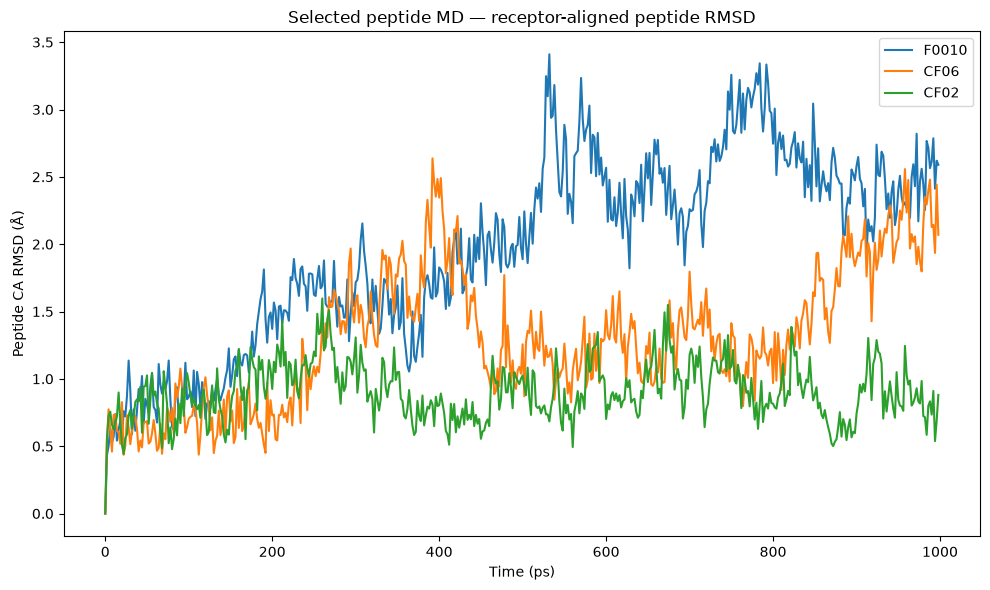

In [27]:
plt.figure(figsize=(10, 6))

for name, result in analysis_results.items():
    df = result["rmsd_df"]

    plt.plot(
        df["time_ps"],
        df["D_CA_RMSD_A"],
        label=name,
    )

plt.xlabel("Time (ps)")
plt.ylabel("Peptide CA RMSD (Å)")
plt.title(
    "Selected peptide MD — receptor-aligned peptide RMSD"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_ROOT
    / "peptide_RMSD_comparison.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 14. Peptide RMSF comparison

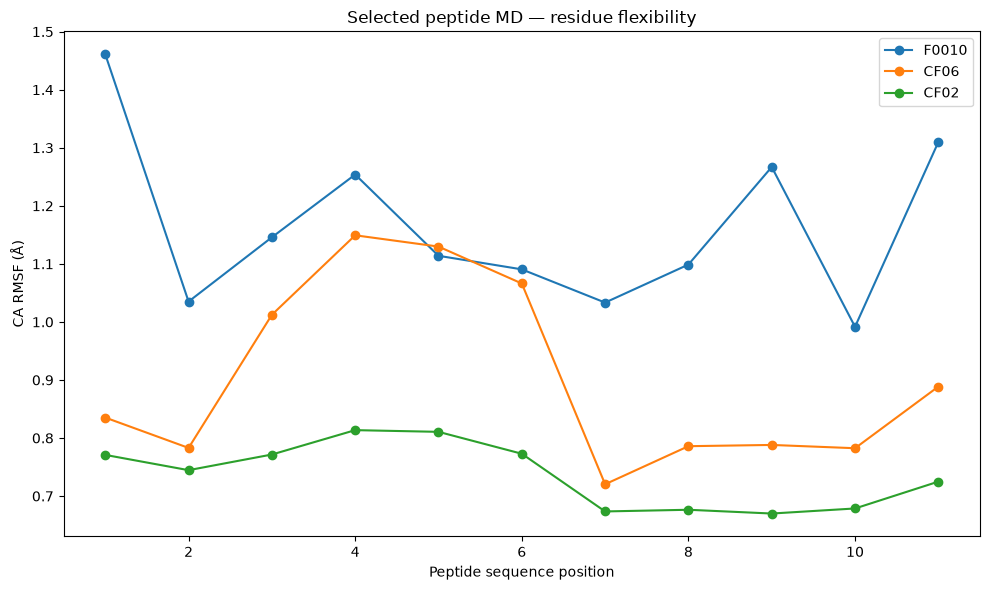

In [28]:
all_peptide_rmsf = []

for name, result in analysis_results.items():

    df = result["rmsf_df"].copy()

    df = df[
        df["chain"]
        == PEPTIDE_CHAIN
    ].copy()

    df["sequence_position"] = (
        np.arange(
            len(df)
        )
        + 1
    )

    all_peptide_rmsf.append(
        df
    )

peptide_rmsf_df = pd.concat(
    all_peptide_rmsf,
    ignore_index=True,
)

peptide_rmsf_df.to_csv(
    OUTPUT_ROOT
    / "peptide_RMSF_comparison.csv",
    index=False,
)

plt.figure(figsize=(10, 6))

for name in CANDIDATES:

    df = peptide_rmsf_df[
        peptide_rmsf_df["candidate"]
        == name
    ]

    plt.plot(
        df["sequence_position"],
        df["CA_RMSF_A"],
        marker="o",
        label=name,
    )

plt.xlabel("Peptide sequence position")
plt.ylabel("CA RMSF (Å)")
plt.title(
    "Selected peptide MD — residue flexibility"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_ROOT
    / "peptide_RMSF_comparison.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 15. Persistent-contact count comparison

,candidate,n_unique_contacts,n_persistent_contacts_50pct,mean_contact_persistence
0,F0010,81,43,0.540519
1,CF06,88,45,0.528545
2,CF02,70,43,0.602886


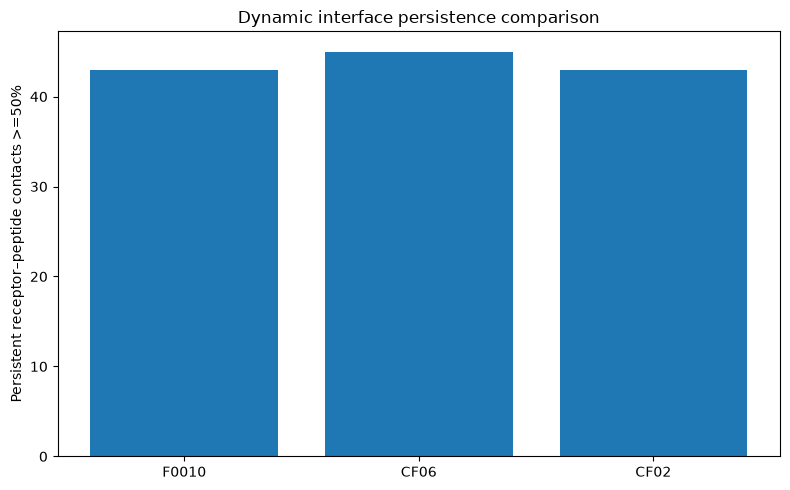

In [29]:
contact_summary_df = comparison_df[
    [
        "candidate",
        "n_unique_contacts",
        "n_persistent_contacts_50pct",
        "mean_contact_persistence",
    ]
].copy()

display(contact_summary_df)

plt.figure(figsize=(8, 5))

plt.bar(
    contact_summary_df["candidate"],
    contact_summary_df[
        "n_persistent_contacts_50pct"
    ],
)

plt.ylabel(
    "Persistent receptor–peptide contacts >=50%"
)
plt.title(
    "Dynamic interface persistence comparison"
)
plt.tight_layout()

plt.savefig(
    OUTPUT_ROOT
    / "persistent_contact_count_comparison.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 16. Identify conserved dynamic receptor contacts

This section asks which receptor residues participate in persistent contacts in all three peptide simulations.


In [30]:
persistent_receptor_sets = {}

for name, result in analysis_results.items():

    df = result["contact_df"]

    persistent = df[
        df["persistent_50pct"]
    ]

    persistent_receptor_sets[name] = set(
        zip(
            persistent["B_resname"],
            persistent["B_resid"],
        )
    )

common_receptor_contacts = set.intersection(
    *persistent_receptor_sets.values()
)

common_receptor_df = pd.DataFrame(
    sorted(
        common_receptor_contacts,
        key=lambda x: x[1],
    ),
    columns=[
        "B_resname",
        "B_resid",
    ],
)

common_receptor_df.to_csv(
    OUTPUT_ROOT
    / "common_persistent_receptor_residues.csv",
    index=False,
)

print(
    "Receptor residues persistently contacted by all candidates:",
    len(common_receptor_df),
)

display(common_receptor_df)


Receptor residues persistently contacted by all candidates: 19


,B_resname,B_resid
0,SER,11
1,ASN,12
2,LYS,13
3,THR,15
4,LEU,17
5,ARG,29
6,LEU,325
7,HIS,346
8,LEU,348
9,ASP,355


## 17. Candidate-specific persistent receptor contacts

In [31]:
specific_rows = []

for name, residue_set in persistent_receptor_sets.items():

    others = [
        s
        for other_name, s
        in persistent_receptor_sets.items()
        if other_name != name
    ]

    other_union = set().union(
        *others
    )

    specific = (
        residue_set
        - other_union
    )

    for resname, resid in sorted(
        specific,
        key=lambda x: x[1],
    ):
        specific_rows.append({
            "candidate": name,
            "B_resname": resname,
            "B_resid": resid,
        })

candidate_specific_df = pd.DataFrame(
    specific_rows
)

candidate_specific_df.to_csv(
    OUTPUT_ROOT
    / "candidate_specific_persistent_receptor_contacts.csv",
    index=False,
)

display(candidate_specific_df)


,candidate,B_resname,B_resid
0,F0010,GLN,16
1,CF06,THR,10
2,CF06,MET,30
3,CF06,ASP,323
4,CF06,SER,324
5,CF06,VAL,350
6,CF06,PHE,380
7,CF06,SER,440


## 18. Mutation-site interpretation

The three sequences differ at specific positions:

```text
F0010  I G E R C Q Y R D L K
CF06   I G E R C Q Y R E L R
CF02   I G E R S Q Y R E L K
```

The comparison focuses especially on:
- D9E shared by CF06 and CF02;
- K11R in CF06;
- C5S in CF02.

This section reports the dynamic persistence of contacts involving those sequence positions.


In [32]:
MUTATION_POSITIONS = {
    "F0010": [],
    "CF06": [9, 11],
    "CF02": [5, 9],
}

mutation_rows = []

for name, result in analysis_results.items():

    df = result["contact_df"].copy()

    peptide_rmsf = (
        result["rmsf_df"]
        .query("chain == @PEPTIDE_CHAIN")
        .reset_index(drop=True)
    )

    peptide_resids = list(
        peptide_rmsf["resid"]
    )

    for seq_pos in MUTATION_POSITIONS[name]:

        if seq_pos < 1 or seq_pos > len(peptide_resids):
            continue

        resid = int(
            peptide_resids[
                seq_pos - 1
            ]
        )

        site_contacts = df[
            df["D_resid"] == resid
        ]

        mutation_rows.append({
            "candidate": name,
            "sequence_position": seq_pos,
            "resid": resid,
            "aa": CANDIDATES[name]["sequence"][
                seq_pos - 1
            ],
            "n_contacts": len(site_contacts),
            "n_persistent_contacts_50pct": int(
                site_contacts["persistent_50pct"]
                .sum()
            ),
            "max_persistence": (
                site_contacts["persistence"].max()
                if len(site_contacts)
                else 0.0
            ),
            "mean_persistence": (
                site_contacts["persistence"].mean()
                if len(site_contacts)
                else 0.0
            ),
        })

mutation_site_df = pd.DataFrame(
    mutation_rows
)

mutation_site_df.to_csv(
    OUTPUT_ROOT
    / "mutation_site_dynamic_support.csv",
    index=False,
)

display(mutation_site_df)


,candidate,sequence_position,resid,aa,n_contacts,n_persistent_contacts_50pct,max_persistence,mean_persistence
0,CF06,9,46,E,5,2,1.000,0.48680
1,CF06,11,48,R,8,6,1.000,0.78625
2,CF02,5,42,S,5,1,0.732,0.16880
3,CF02,9,46,E,6,3,0.998,0.48300


## 19. Automatic ranking

In [33]:
ranking_df = comparison_df.copy()

# Lower peptide RMSD/RMSF are favorable.
def minmax_inverse(series):
    s = series.astype(float)

    if np.isclose(
        s.max(),
        s.min(),
    ):
        return pd.Series(
            np.ones(len(s)),
            index=s.index,
        )

    return (
        s.max() - s
    ) / (
        s.max() - s.min()
    )

def minmax_positive(series):
    s = series.astype(float)

    if np.isclose(
        s.max(),
        s.min(),
    ):
        return pd.Series(
            np.ones(len(s)),
            index=s.index,
        )

    return (
        s - s.min()
    ) / (
        s.max() - s.min()
    )

ranking_df["rmsd_component"] = (
    minmax_inverse(
        ranking_df["mean_D_CA_RMSD_A"]
    )
)

ranking_df["rmsf_component"] = (
    minmax_inverse(
        ranking_df["mean_D_CA_RMSF_A"]
    )
)

ranking_df["contact_component"] = (
    minmax_positive(
        ranking_df[
            "n_persistent_contacts_50pct"
        ]
    )
)

ranking_df["persistence_component"] = (
    minmax_positive(
        ranking_df[
            "mean_contact_persistence"
        ]
    )
)

ranking_df["dynamic_comparison_score"] = (
    0.30
    * ranking_df["rmsd_component"]
    + 0.20
    * ranking_df["rmsf_component"]
    + 0.30
    * ranking_df["contact_component"]
    + 0.20
    * ranking_df["persistence_component"]
)

ranking_df = ranking_df.sort_values(
    "dynamic_comparison_score",
    ascending=False,
).reset_index(drop=True)

ranking_df.insert(
    0,
    "dynamic_rank",
    np.arange(len(ranking_df)) + 1,
)

ranking_df.to_csv(
    OUTPUT_ROOT
    / "07d_dynamic_candidate_ranking.csv",
    index=False,
)

display(
    ranking_df[
        [
            "dynamic_rank",
            "candidate",
            "sequence",
            "dynamic_comparison_score",
            "mean_D_CA_RMSD_A",
            "mean_D_CA_RMSF_A",
            "n_persistent_contacts_50pct",
            "mean_contact_persistence",
        ]
    ]
)


,dynamic_rank,candidate,sequence,dynamic_comparison_score,mean_D_CA_RMSD_A,mean_D_CA_RMSF_A,n_persistent_contacts_50pct,mean_contact_persistence
0,1,CF02,IGERSQYRELK,0.700000,0.901385,0.737052,43,0.602886
1,2,CF06,IGERCQYRELR,0.611385,1.293427,0.903728,45,0.528545
2,3,F0010,IGERCQYRDLK,0.032212,1.965916,1.163706,43,0.540519


### Important note about the ranking

`dynamic_comparison_score` is **not a physical binding energy**.

It is only a compact descriptive score combining:
- peptide structural drift;
- peptide flexibility;
- persistent-contact count;
- average contact persistence.

The raw metrics should always be reported together with the score.


## 20. Generate final report

In [34]:
report_lines = []

report_lines.append(
    "# 07d - Selected Peptide MD Comparison"
)
report_lines.append("")

report_lines.append(
    f"- Mode: {RUN_LABEL}"
)
report_lines.append(
    f"- Production per candidate: {PRODUCTION_PS:.1f} ps"
)
report_lines.append(
    f"- Contact cutoff: {CONTACT_CUTOFF_A:.1f} A"
)
report_lines.append(
    f"- Persistence threshold: {PERSISTENCE_THRESHOLD:.0%}"
)
report_lines.append("")

report_lines.append(
    "## Candidate summary"
)

for row in comparison_df.itertuples():
    report_lines.append(
        (
            f"- {row.candidate}: "
            f"peptide RMSD={row.mean_D_CA_RMSD_A:.3f} A; "
            f"peptide RMSF={row.mean_D_CA_RMSF_A:.3f} A; "
            f"persistent contacts={row.n_persistent_contacts_50pct}; "
            f"mean persistence={row.mean_contact_persistence:.3f}; "
            f"QC={row.QC_PASS}"
        )
    )

report_lines.append("")
report_lines.append(
    "## Dynamic ranking"
)

for row in ranking_df.itertuples():
    report_lines.append(
        (
            f"{row.dynamic_rank}. {row.candidate} "
            f"(score={row.dynamic_comparison_score:.3f})"
        )
    )

report_lines.append("")
report_lines.append(
    "## Interpretation"
)

report_lines.append(
    "The comparison tests whether CF06 and CF02 preserve "
    "or improve the dynamic receptor-peptide interface "
    "relative to the natural F0010 reference."
)

report_lines.append(
    "The ranking is descriptive and does not constitute "
    "a binding free-energy calculation or experimental validation."
)

report_text = "\n".join(
    report_lines
)

report_path = (
    OUTPUT_ROOT
    / "07d_selected_peptide_MD_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(report_text)
print("\nReport:", report_path.resolve())


# 07d - Selected Peptide MD Comparison

- Mode: production_1ns
- Production per candidate: 1000.0 ps
- Contact cutoff: 4.5 A
- Persistence threshold: 50%

## Candidate summary
- F0010: peptide RMSD=1.966 A; peptide RMSF=1.164 A; persistent contacts=43; mean persistence=0.541; QC=True
- CF06: peptide RMSD=1.293 A; peptide RMSF=0.904 A; persistent contacts=45; mean persistence=0.529; QC=True
- CF02: peptide RMSD=0.901 A; peptide RMSF=0.737 A; persistent contacts=43; mean persistence=0.603; QC=True

## Dynamic ranking
1. CF02 (score=0.700)
2. CF06 (score=0.611)
3. F0010 (score=0.032)

## Interpretation
The comparison tests whether CF06 and CF02 preserve or improve the dynamic receptor-peptide interface relative to the natural F0010 reference.
The ranking is descriptive and does not constitute a binding free-energy calculation or experimental validation.

Report: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns/07d_selected_peptide_MD

# 21. Interpretation and next step

### If `FAST_TEST_MODE=True`

Use the result only to confirm:
- all three structures are valid;
- OpenMM setup succeeds;
- trajectories are produced;
- analysis completes;
- no candidate rapidly dissociates in the very short test.

Then rerun with:

```python
FAST_TEST_MODE = False
```

for the 1 ns comparison.

### After the 1 ns comparison

The next Pipeline 3 step can be:

```text
07e — MM-GBSA / endpoint binding-energy comparison
```

for:

```text
F0010
CF06
CF02
```

using snapshots from the peptide-complex trajectories.

This would add an energetic comparison to the structural/dynamic evidence obtained here.
